# Heston Model Pricing Playground

This notebook exercises the pricing routines implemented in `src/heston_model.py` without running the full calibration pipeline. It demonstrates:

- How to instantiate the `HestonModel` with reasonable parameters.
- Comparing numerical integration techniques (`quad`, `rectangular`) versus the Carr–Madan FFT.
- Visual diagnostics for grids of strikes and maturities.

> **Note**: Make sure the project virtual environment is activated so the notebook can import project modules.


In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
from scipy.optimize import brentq
from scipy.stats import norm
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go

PROJECT_ROOT = Path("..")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.heston_model import HestonModel

# Research paper quality plotting settings
plt.rcParams.update({
    'font.size': 11,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 14,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    'axes.linewidth': 1.0,
    'grid.linewidth': 0.5,
    'lines.linewidth': 1.5,
    'patch.linewidth': 0.5,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.axisbelow': True,
})

# Color palette for research papers
COLORS = {
    'primary': '#2E86AB',
    'secondary': '#A23B72',
    'accent': '#F18F01',
    'success': '#C73E1D',
    'neutral': '#6C757D',
    'dark': '#212529',
}

## Baseline model parameters

In [2]:
params = {
    "kappa": 1.5,
    "theta": 0.04,
    "sigma": 0.3,
    "rho": -0.7,
    "v0": 0.04,
    "r": 0.02,
    "q": 0.00,
    "lambd": 0.0,
}
model = HestonModel(**params)
params

{'kappa': 1.5,
 'theta': 0.04,
 'sigma': 0.3,
 'rho': -0.7,
 'v0': 0.04,
 'r': 0.02,
 'q': 0.0,
 'lambd': 0.0}

## Black-Scholes helper functions

To translate Heston prices into implied volatilities, we need a Black–Scholes call pricer and a root-finder for the volatility parameter. These utilities are reused in the volatility-surface section further down (and can later ingest market prices for comparison).


In [3]:
def bs_call_price(S, K, tau, r, q, vol):
    if tau <= 0:
        return max(S - K, 0.0)
    fwd = S * np.exp((r - q) * tau)
    discount = np.exp(-r * tau)
    vol_sqrt = vol * np.sqrt(tau)
    d1 = (np.log(fwd / K) + 0.5 * vol**2 * tau) / vol_sqrt
    d2 = d1 - vol_sqrt
    return discount * (fwd * norm.cdf(d1) - K * norm.cdf(d2))


def implied_vol(price, S, K, tau, r, q, tol=1e-6):
    if price <= 0:
        return np.nan
    intrinsic = max(S * np.exp(-q * tau) - K * np.exp(-r * tau), 0)
    if price < intrinsic + 1e-12:
        return np.nan
    def objective(vol):
        return bs_call_price(S, K, tau, r, q, vol) - price
    try:
        return brentq(objective, 1e-6, 5.0, xtol=tol)
    except ValueError:
        return np.nan

In [4]:
S0 = 100
K = 100
tau = 1.0

price_fft = model.call_price(S0, K, tau, method="fft")
price_quad = model.call_price(S0, K, tau, method="quad")
price_rect = model.call_price(S0, K, tau, method="rectangular")

pd.DataFrame(
    {
        "method": ["fft", "quad", "rectangular"],
        "price": [price_fft, price_quad, price_rect],
    }
)

,method,price
0,fft,8.629022
1,quad,9.080608
2,rectangular,9.067780


## Price surface across strikes and maturities

Next we evaluate a grid of strikes and maturities using the FFT pricer and visualise the surface.


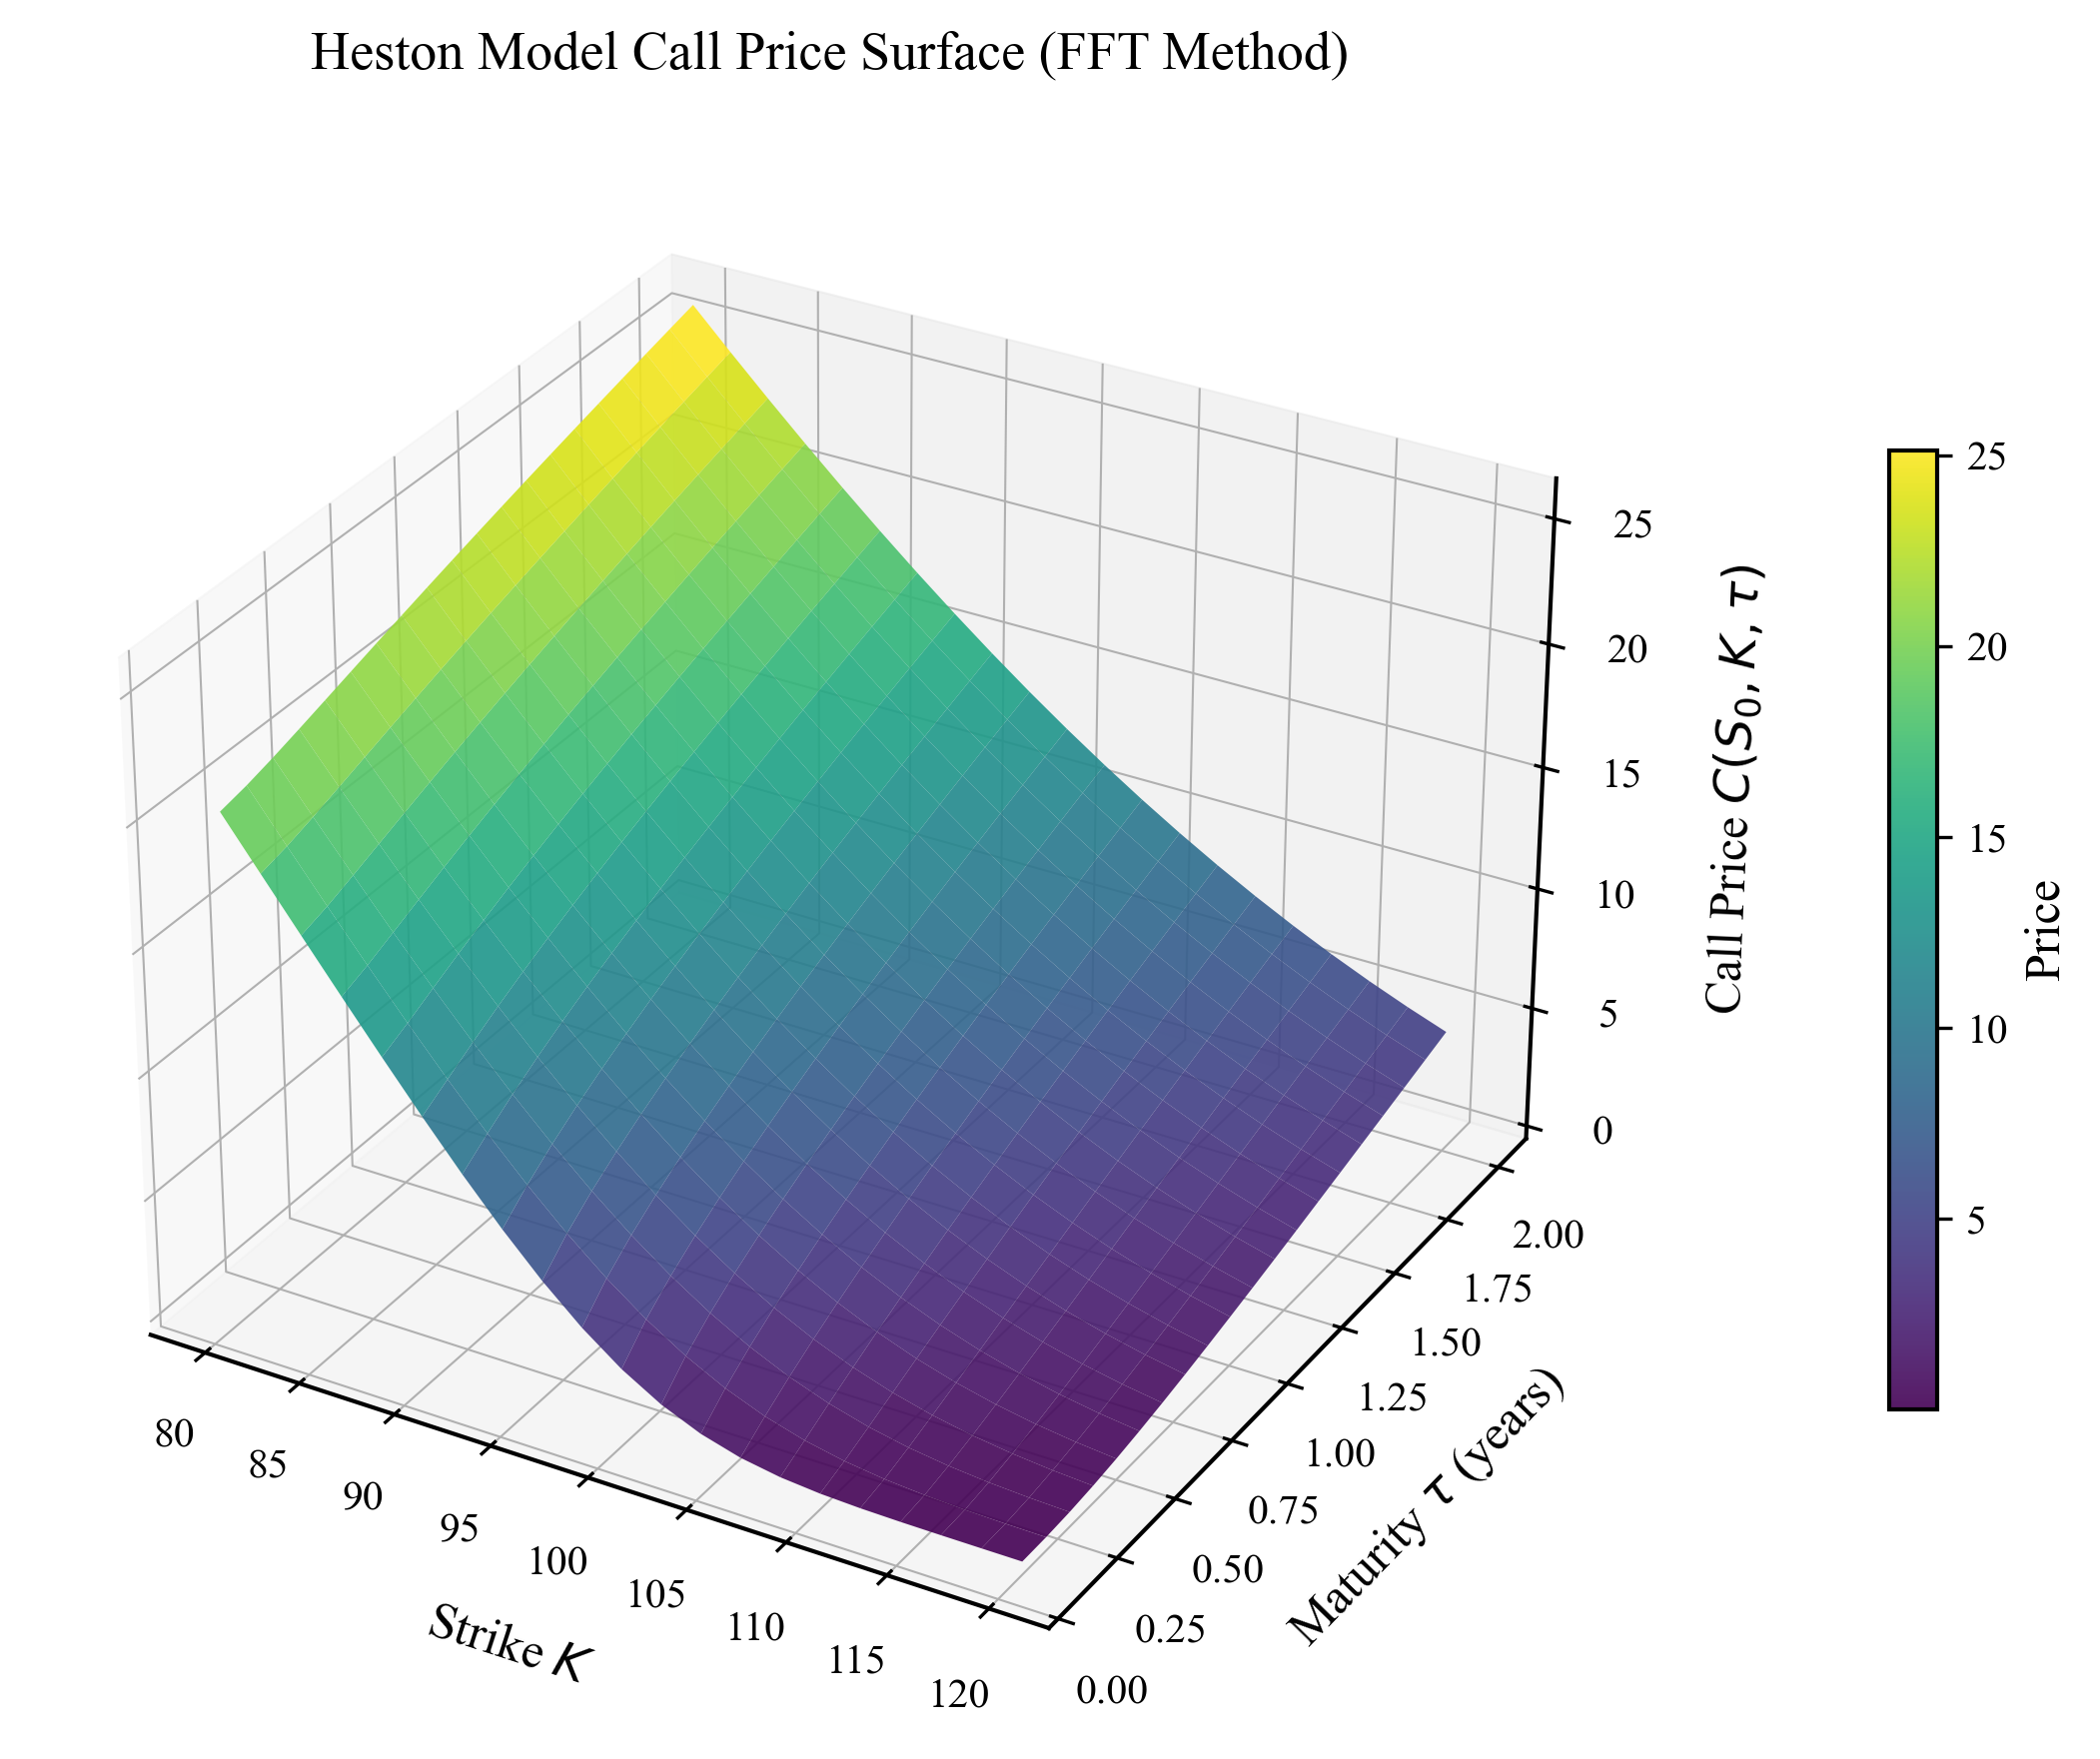

In [5]:
strikes = np.sort(np.linspace(80, 120, 21))
maturities = np.sort(np.linspace(0.1, 2.0, 20))

surface = np.zeros((len(maturities), len(strikes)))
for i, tau in enumerate(maturities):
    for j, K in enumerate(strikes):
        surface[i, j] = model.call_price(S0, K, tau, method="fft")

# Interactive Plotly surface rendered in the next cell.
surface[:3, :3]  # quick sanity peek

# Matplotlib 3D surface for publication
fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection='3d')
K_grid, T_grid = np.meshgrid(strikes, maturities)
surf = ax.plot_surface(K_grid, T_grid, surface, cmap='viridis', alpha=0.9,
                       linewidth=0, antialiased=True, edgecolor='none')
ax.set_xlabel(r'Strike $K$', fontsize=12, labelpad=8)
ax.set_ylabel(r'Maturity $\tau$ (years)', fontsize=12, labelpad=8)
ax.set_zlabel(r'Call Price $C(S_0, K, \tau)$', fontsize=12, labelpad=8)
ax.set_title('Heston Model Call Price Surface (FFT Method)', fontsize=13, pad=15)
fig.colorbar(surf, ax=ax, shrink=0.6, aspect=20, pad=0.1, label='Price')
plt.tight_layout()
plt.savefig('../figures/heston_price_surface.png', dpi=300, bbox_inches='tight')
plt.show()

## Model implied volatility surface

With the Black–Scholes helpers we can convert Heston prices into implied volatilities. This is what we will eventually compare against the market surface after calibration. The grid below uses moderately tight FFT parameters so the prices are stable.


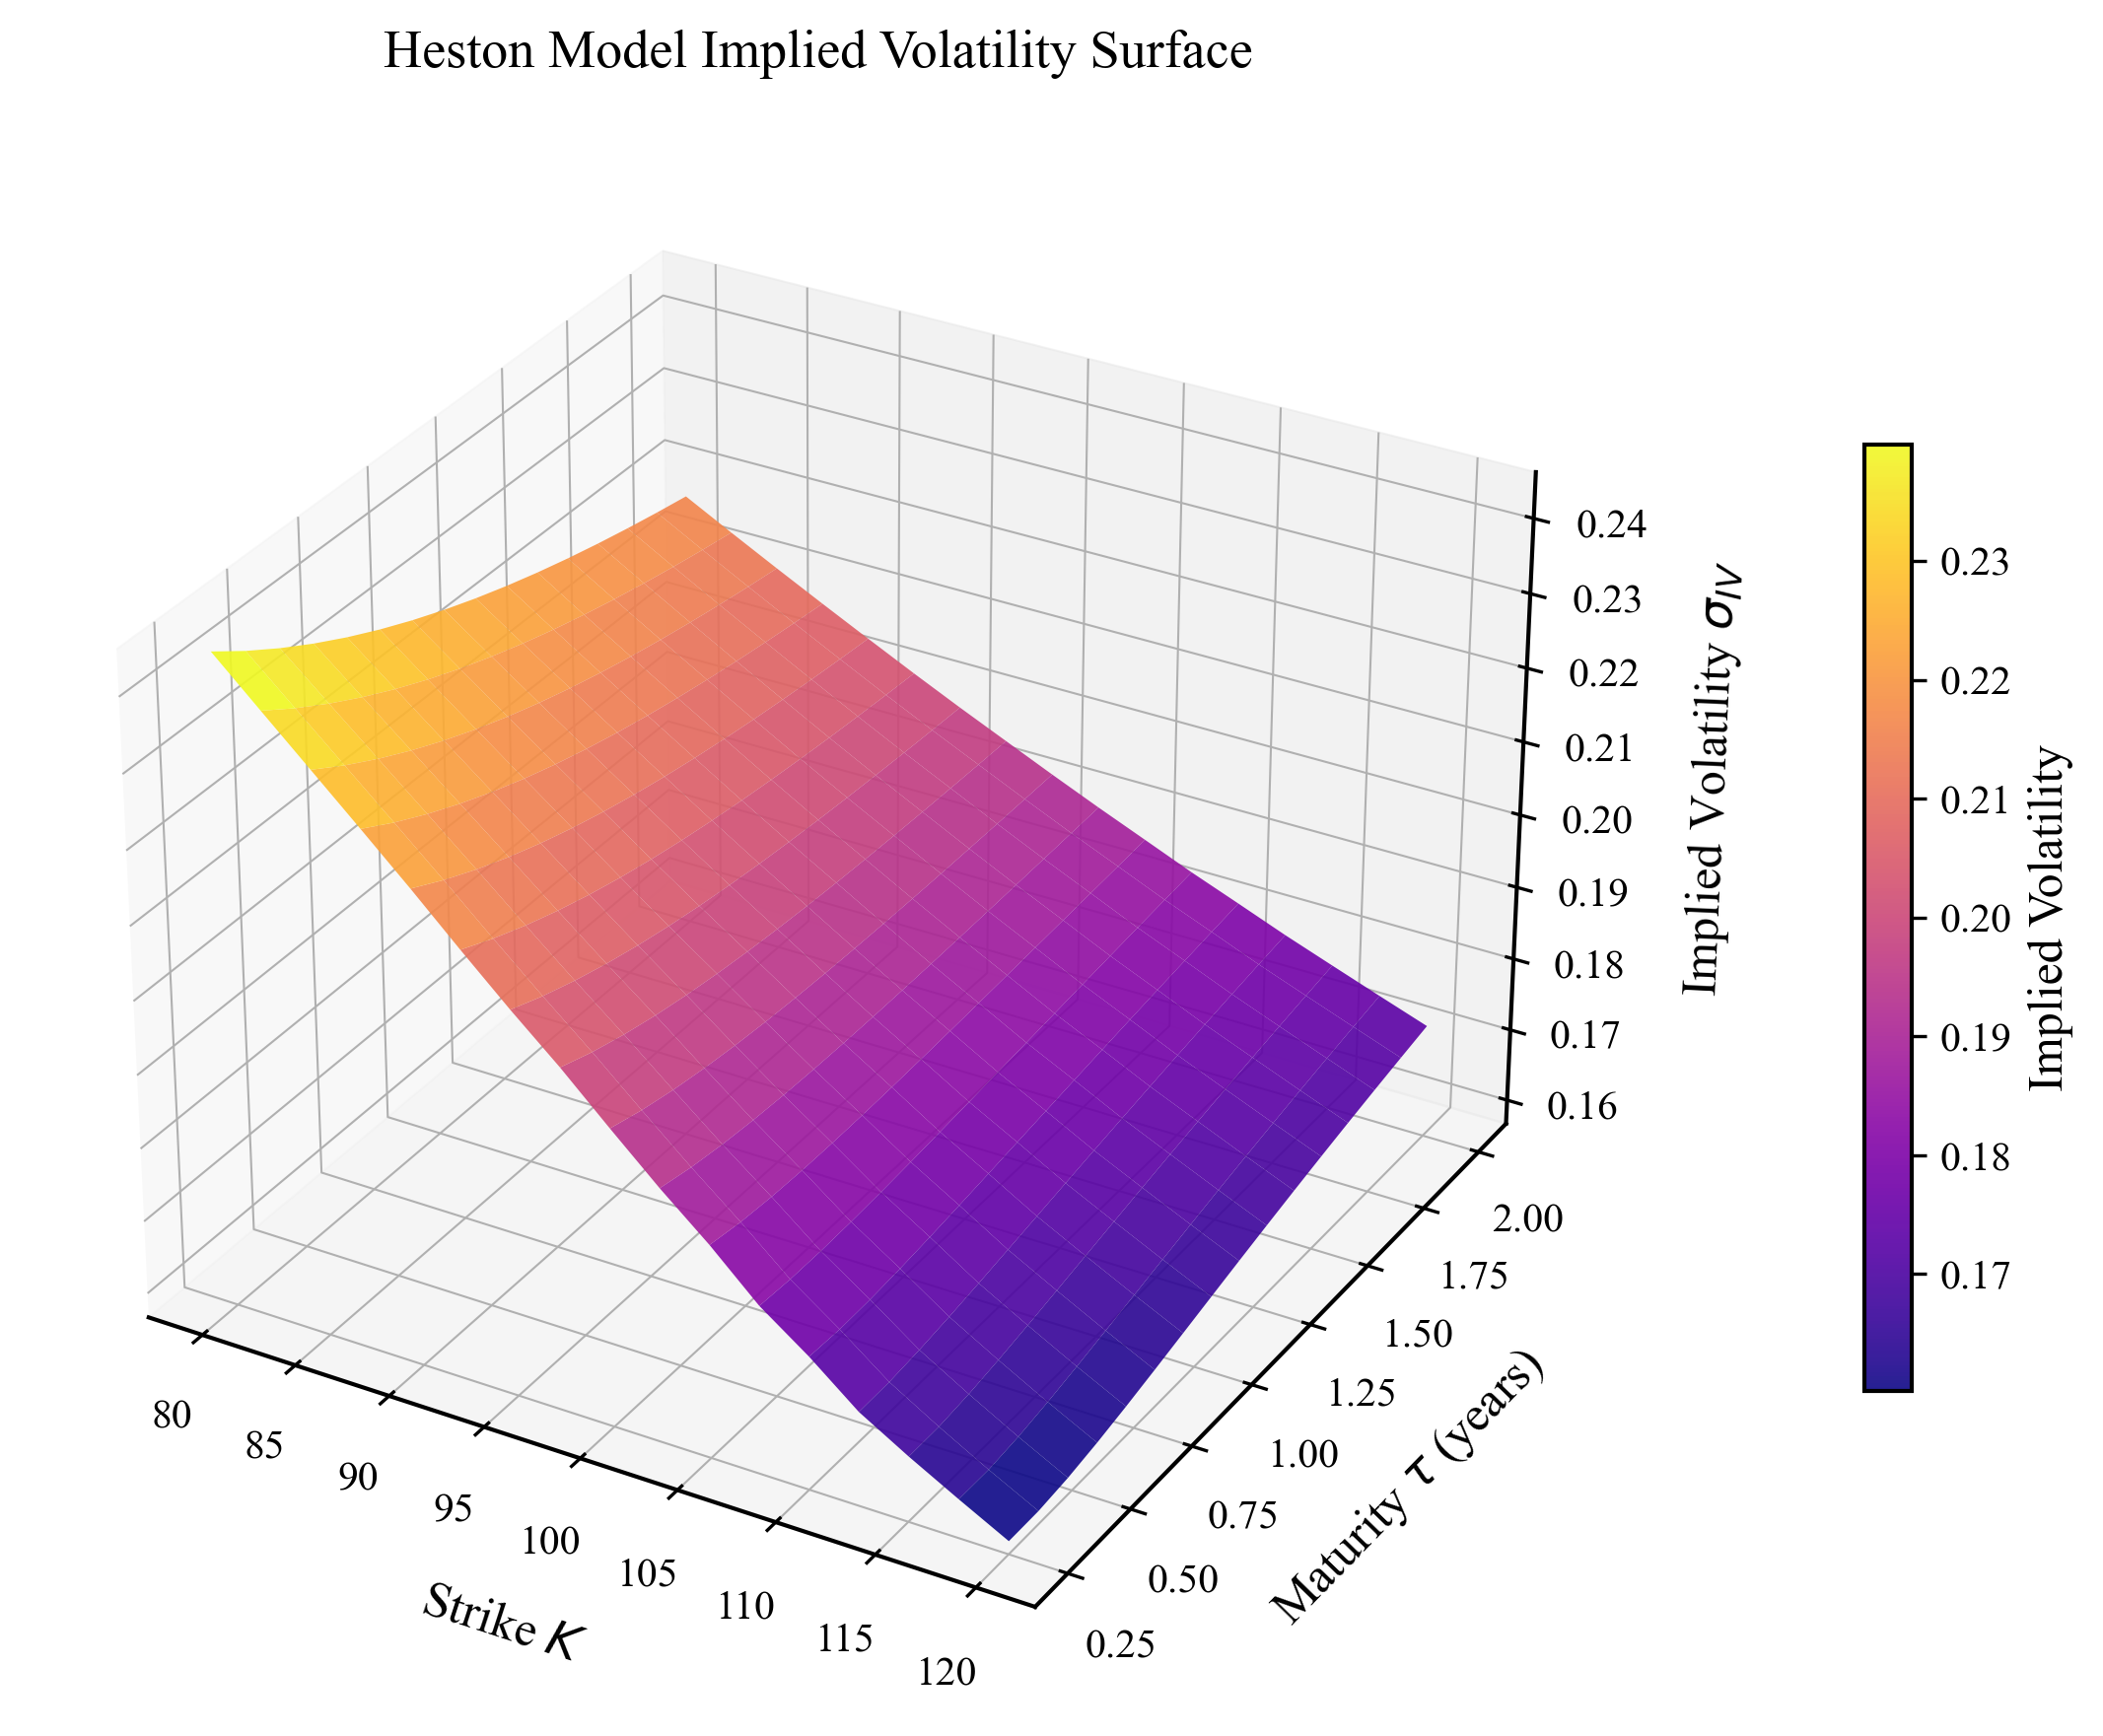

In [6]:
vol_strikes = np.sort(np.linspace(80, 120, 17))
vol_maturities = np.sort(np.linspace(0.25, 2.0, 16))
fft_params = {"N": 8192, "eta": 0.05, "alpha": 1.3}

implied_vols = np.zeros((len(vol_maturities), len(vol_strikes)))
prices_grid = np.zeros_like(implied_vols)

for i, tau in enumerate(vol_maturities):
    for j, K in enumerate(vol_strikes):
        price = model.call_price_fft(S0, K, tau, **fft_params)
        prices_grid[i, j] = price
        implied_vols[i, j] = implied_vol(price, S0, K, tau, model.r, model.q)

# Interactive Plotly surface rendered in the next cell.
implied_vols[:3, :3]

# Matplotlib 3D surface for publication
fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection='3d')
K_vol_grid, T_vol_grid = np.meshgrid(vol_strikes, vol_maturities)
surf = ax.plot_surface(K_vol_grid, T_vol_grid, implied_vols, cmap='plasma', alpha=0.9,
                       linewidth=0, antialiased=True, edgecolor='none')
ax.set_xlabel(r'Strike $K$', fontsize=12, labelpad=8)
ax.set_ylabel(r'Maturity $\tau$ (years)', fontsize=12, labelpad=8)
ax.set_zlabel(r'Implied Volatility $\sigma_{IV}$', fontsize=12, labelpad=8)
ax.set_title('Heston Model Implied Volatility Surface', fontsize=13, pad=15)
fig.colorbar(surf, ax=ax, shrink=0.6, aspect=20, pad=0.1, label='Implied Volatility')
plt.tight_layout()
plt.savefig('../figures/heston_iv_surface.png', dpi=300, bbox_inches='tight')
plt.show()

## FFT parameter tuning

The defaults (`N=4096`, `eta=0.25`, `alpha=1.5`) prioritise speed over accuracy, so the FFT price can diverge from the quadrature reference. The grid-search below mimics the workflow discussed in the Quant Guild FFT notebook: tighten the grid (larger `N`, smaller `eta`) and tweak the damping factor `alpha` until the price converges to the quad benchmark.


In [7]:
baseline_price = model.call_price(S0, K, tau, method="quad")

search_grid = {
    "N": [4096, 8192, 16384],
    "eta": [0.25, 0.10, 0.05, 0.025],
    "alpha": [1.7, 1.5, 1.3, 1.1],
}

records = []
step = 0
for N in search_grid["N"]:
    for eta in search_grid["eta"]:
        for alpha in search_grid["alpha"]:
            step += 1
            fft_price = model.call_price_fft(S0, K, tau, N=N, eta=eta, alpha=alpha)
            error = abs(fft_price - baseline_price)
            records.append(
                {
                    "step": step,
                    "N": N,
                    "eta": eta,
                    "alpha": alpha,
                    "fft_price": fft_price,
                    "quad_price": baseline_price,
                    "abs_error": error,
                }
            )
search_df = pd.DataFrame(records)

best_df = search_df.nsmallest(5, "abs_error")
search_df

,step,N,eta,alpha,fft_price,quad_price,abs_error
0,1,4096,0.250,1.7,4.504144,4.528819,0.024675
1,2,4096,0.250,1.5,4.504144,4.528819,0.024675
2,3,4096,0.250,1.3,4.504142,4.528819,0.024678
3,4,4096,0.250,1.1,4.504111,4.528819,0.024708
4,5,4096,0.100,1.7,4.505349,4.528819,0.023470
5,6,4096,0.100,1.5,4.505349,4.528819,0.023470
6,7,4096,0.100,1.3,4.505349,4.528819,0.023470
7,8,4096,0.100,1.1,4.505349,4.528819,0.023470
8,9,4096,0.050,1.7,4.507340,4.528819,0.021480
9,10,4096,0.050,1.5,4.507340,4.528819,0.021480


Five best parameter sets (lowest |FFT - quad|):


,step,N,eta,alpha,fft_price,quad_price,abs_error
15,16,4096,0.025,1.1,4.511238,4.528819,0.017582
14,15,4096,0.025,1.3,4.511238,4.528819,0.017582
13,14,4096,0.025,1.5,4.511238,4.528819,0.017582
12,13,4096,0.025,1.7,4.511238,4.528819,0.017582
31,32,8192,0.025,1.1,4.507340,4.528819,0.021480


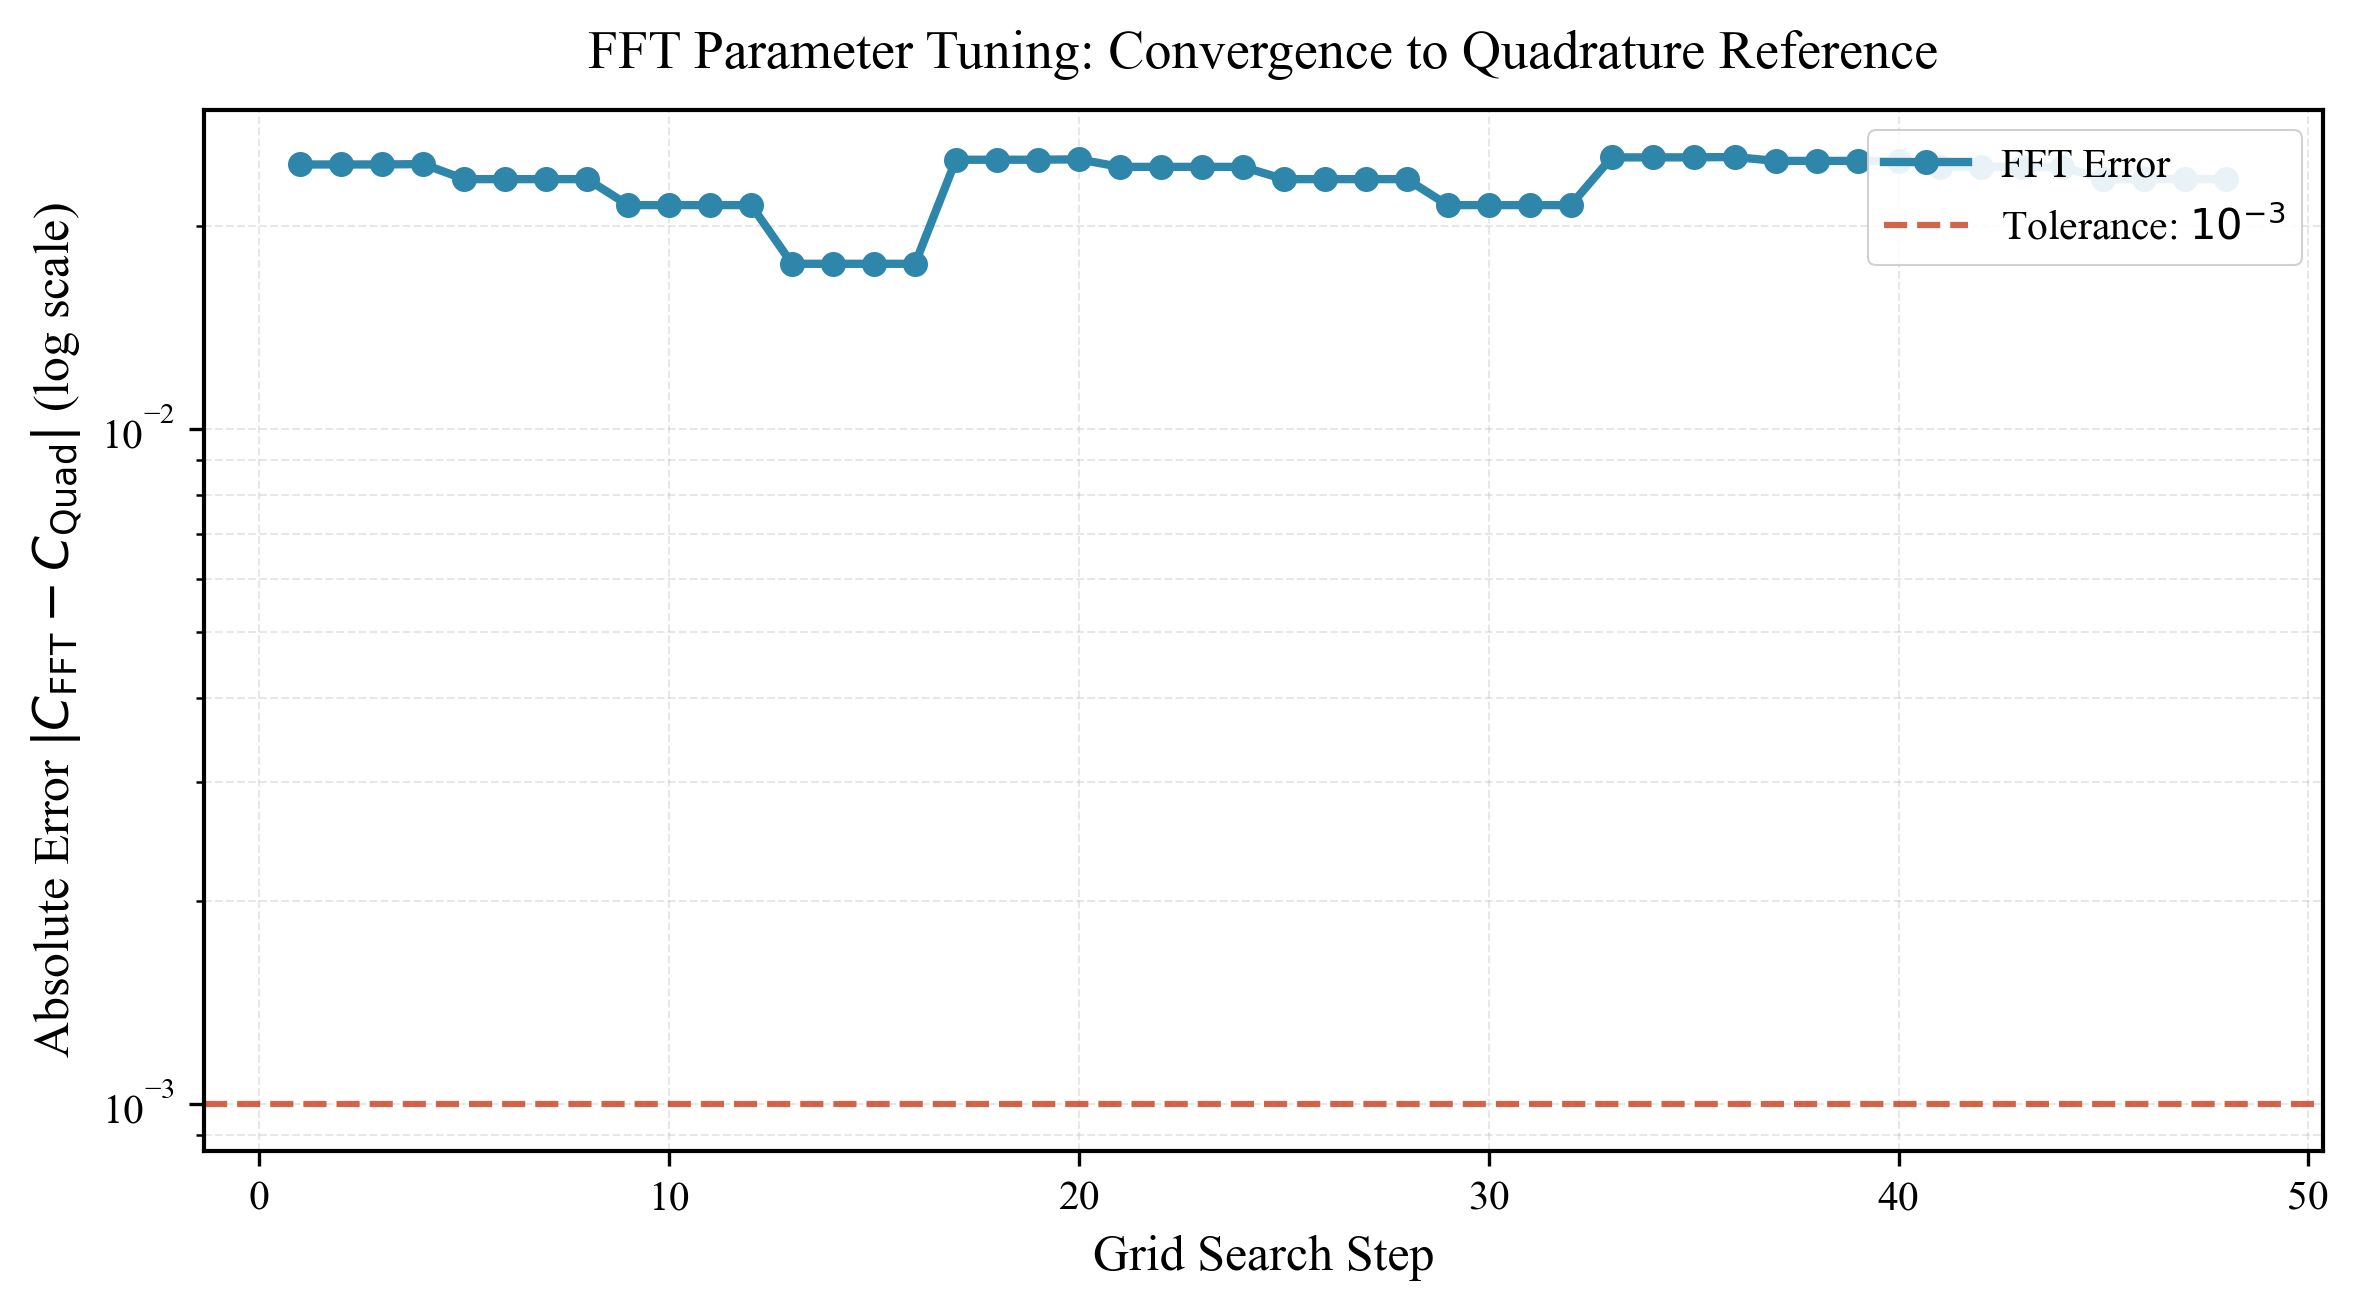

In [8]:
print("Five best parameter sets (lowest |FFT - quad|):")
display(best_df)

ordered = search_df.sort_values("step")
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(ordered["step"], ordered["abs_error"], marker="o", color=COLORS['primary'], 
        linewidth=2, markersize=5, label='FFT Error')
ax.set_yscale("log")
ax.set_xlabel("Grid Search Step", fontsize=12)
ax.set_ylabel(r"Absolute Error $|C_{\text{FFT}} - C_{\text{Quad}}|$ (log scale)", fontsize=12)
ax.set_title("FFT Parameter Tuning: Convergence to Quadrature Reference", fontsize=13, pad=10)
ax.axhline(1e-3, color=COLORS['success'], linestyle="--", linewidth=1.5, 
           label=r'Tolerance: $10^{-3}$', alpha=0.8)
ax.legend(loc="upper right", framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--', which='both')
plt.tight_layout()

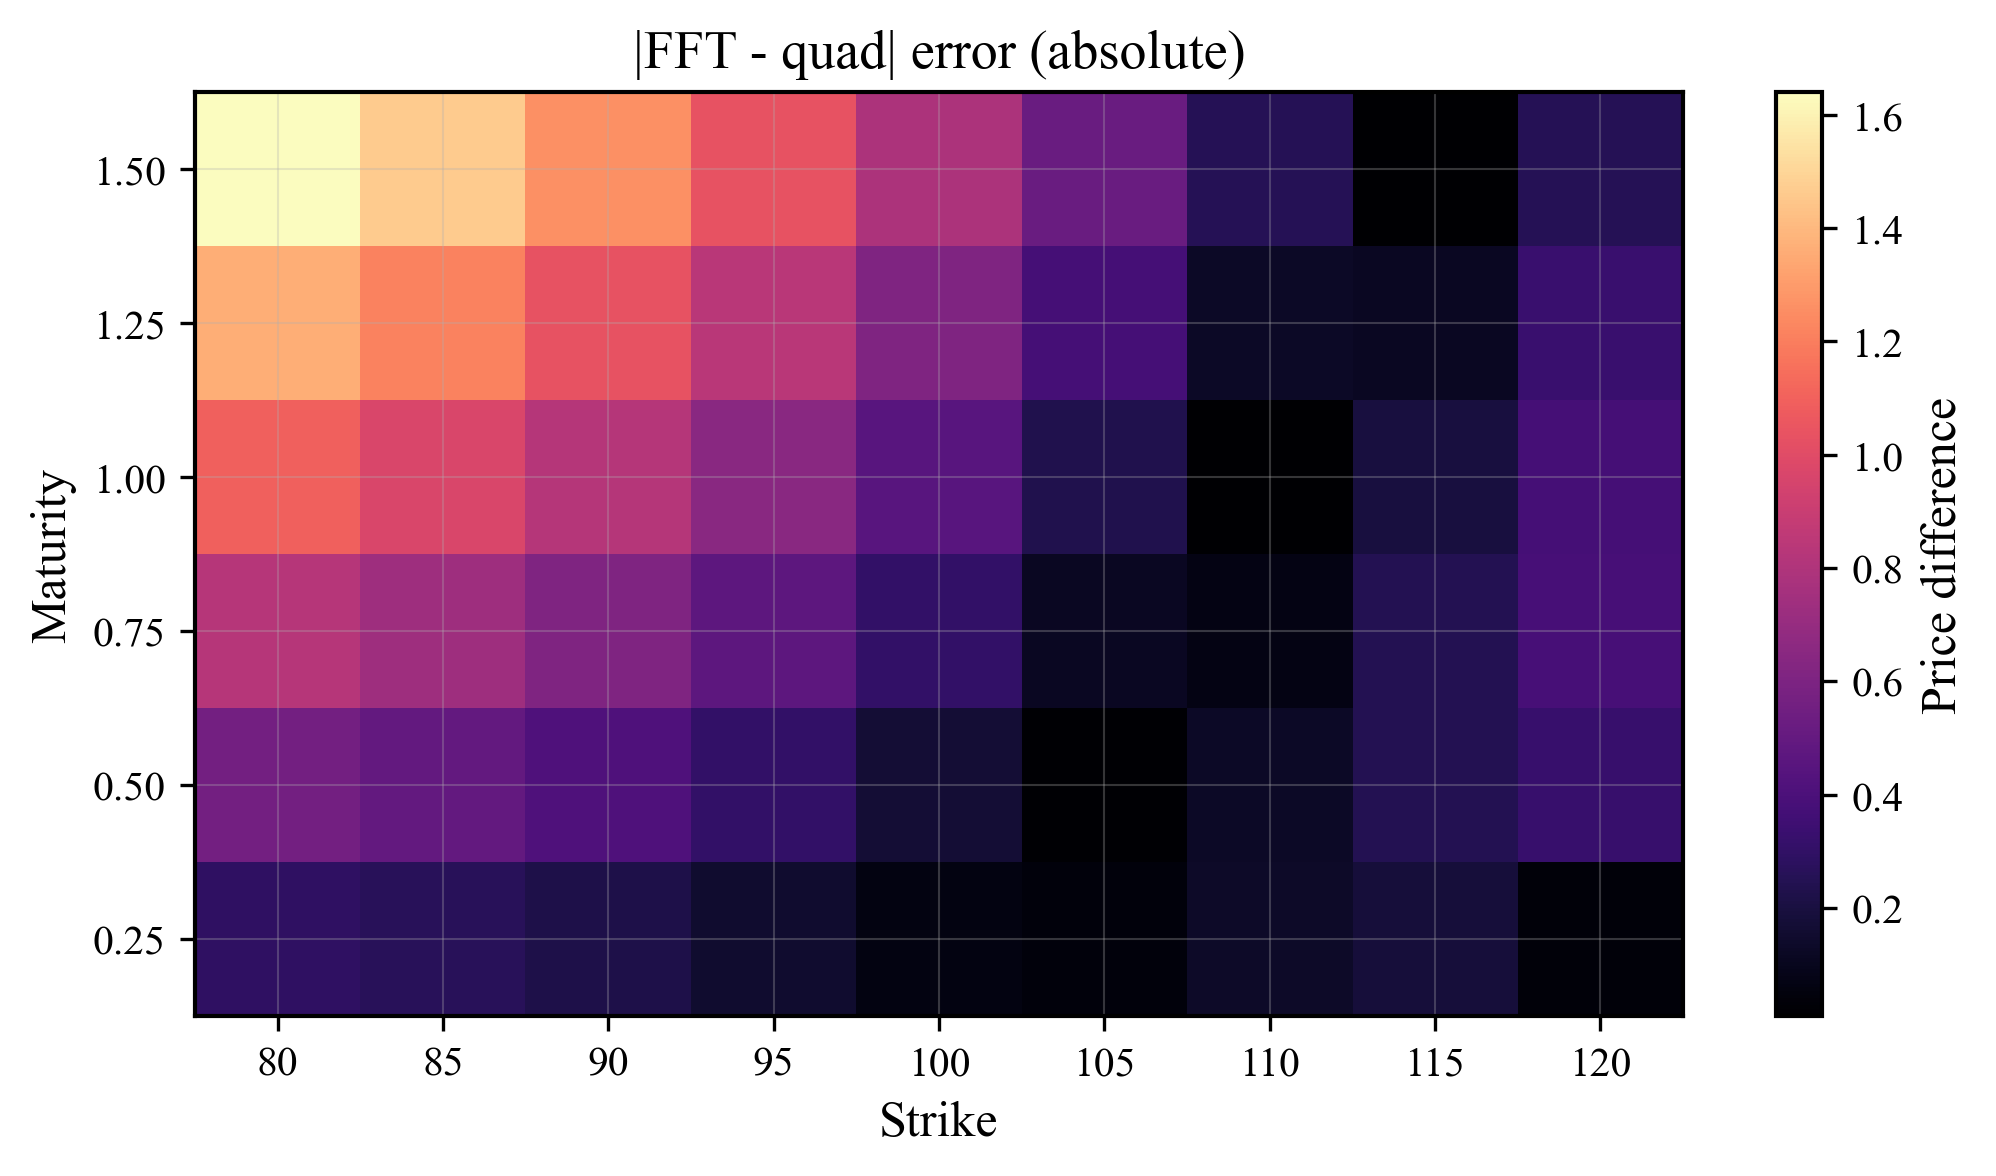

In [9]:
test_strikes = np.linspace(80, 120, 9)
test_maturities = np.linspace(0.25, 1.5, 6)

records = []
for tau in test_maturities:
    for K in test_strikes:
        fft_price = model.call_price(S0, K, tau, method="fft")
        quad_price = model.call_price(S0, K, tau, method="quad")
        records.append(
            {
                "strike": K,
                "maturity": tau,
                "fft": fft_price,
                "quad": quad_price,
                "abs_error": abs(fft_price - quad_price),
            }
        )
error_df = pd.DataFrame(records)
error_df_pivot = error_df.pivot_table(
    index="maturity", columns="strike", values="abs_error"
)

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(error_df_pivot, aspect="auto", cmap="magma", origin="lower")
ax.set_xticks(range(len(test_strikes)))
ax.set_xticklabels([f"{k:.0f}" for k in test_strikes])
ax.set_yticks(range(len(test_maturities)))
ax.set_yticklabels([f"{t:.2f}" for t in test_maturities])
ax.set_xlabel("Strike")
ax.set_ylabel("Maturity")
ax.set_title("|FFT - quad| error (absolute)")
fig.colorbar(im, ax=ax, label="Price difference")

## Parameter sensitivity sweeps

To illustrate how each Heston parameter influences option prices and implied vol, we vary one parameter at a time while keeping the others fixed. Each sweep recalculates the ATM one-year call price and implied vol so you can see qualitative trends. Run this section in a fresh kernel without worrying about order—the code below redefines the baseline parameters if they are not already set.

In [10]:
baseline_params = params.copy()
S0 = locals().get("S0", 100)
K = locals().get("K", 100)
tau = locals().get("tau", 1.0)

In [11]:
def sweep_parameter(param_name, values):
    records = []
    for val in values:
        params = baseline_params.copy()
        params[param_name] = val
        model = HestonModel(**params)
        price = model.call_price_fft(S0, K, tau, N=8192, eta=0.05, alpha=1.3)
        iv = implied_vol(price, S0, K, tau, model.r, model.q)
        records.append({"value": val, "price": price, "iv": iv})
    return pd.DataFrame(records)

sweeps = {
    "theta": np.linspace(0.02, 0.08, 6),
    "kappa": np.linspace(0.5, 3.0, 6),
    "sigma": np.linspace(0.1, 0.6, 6),
    "rho": np.linspace(-0.9, 0.2, 6),
    "v0": np.linspace(0.02, 0.08, 6),
}

sweep_results = {name: sweep_parameter(name, vals) for name, vals in sweeps.items()}
sweep_results["theta"]

,value,price,iv
0,0.020,1.548376,0.129938
1,0.032,2.403944,0.153900
2,0.044,3.233671,0.174974
3,0.056,4.022583,0.193886
4,0.068,4.770404,0.211150
5,0.080,5.480504,0.227117


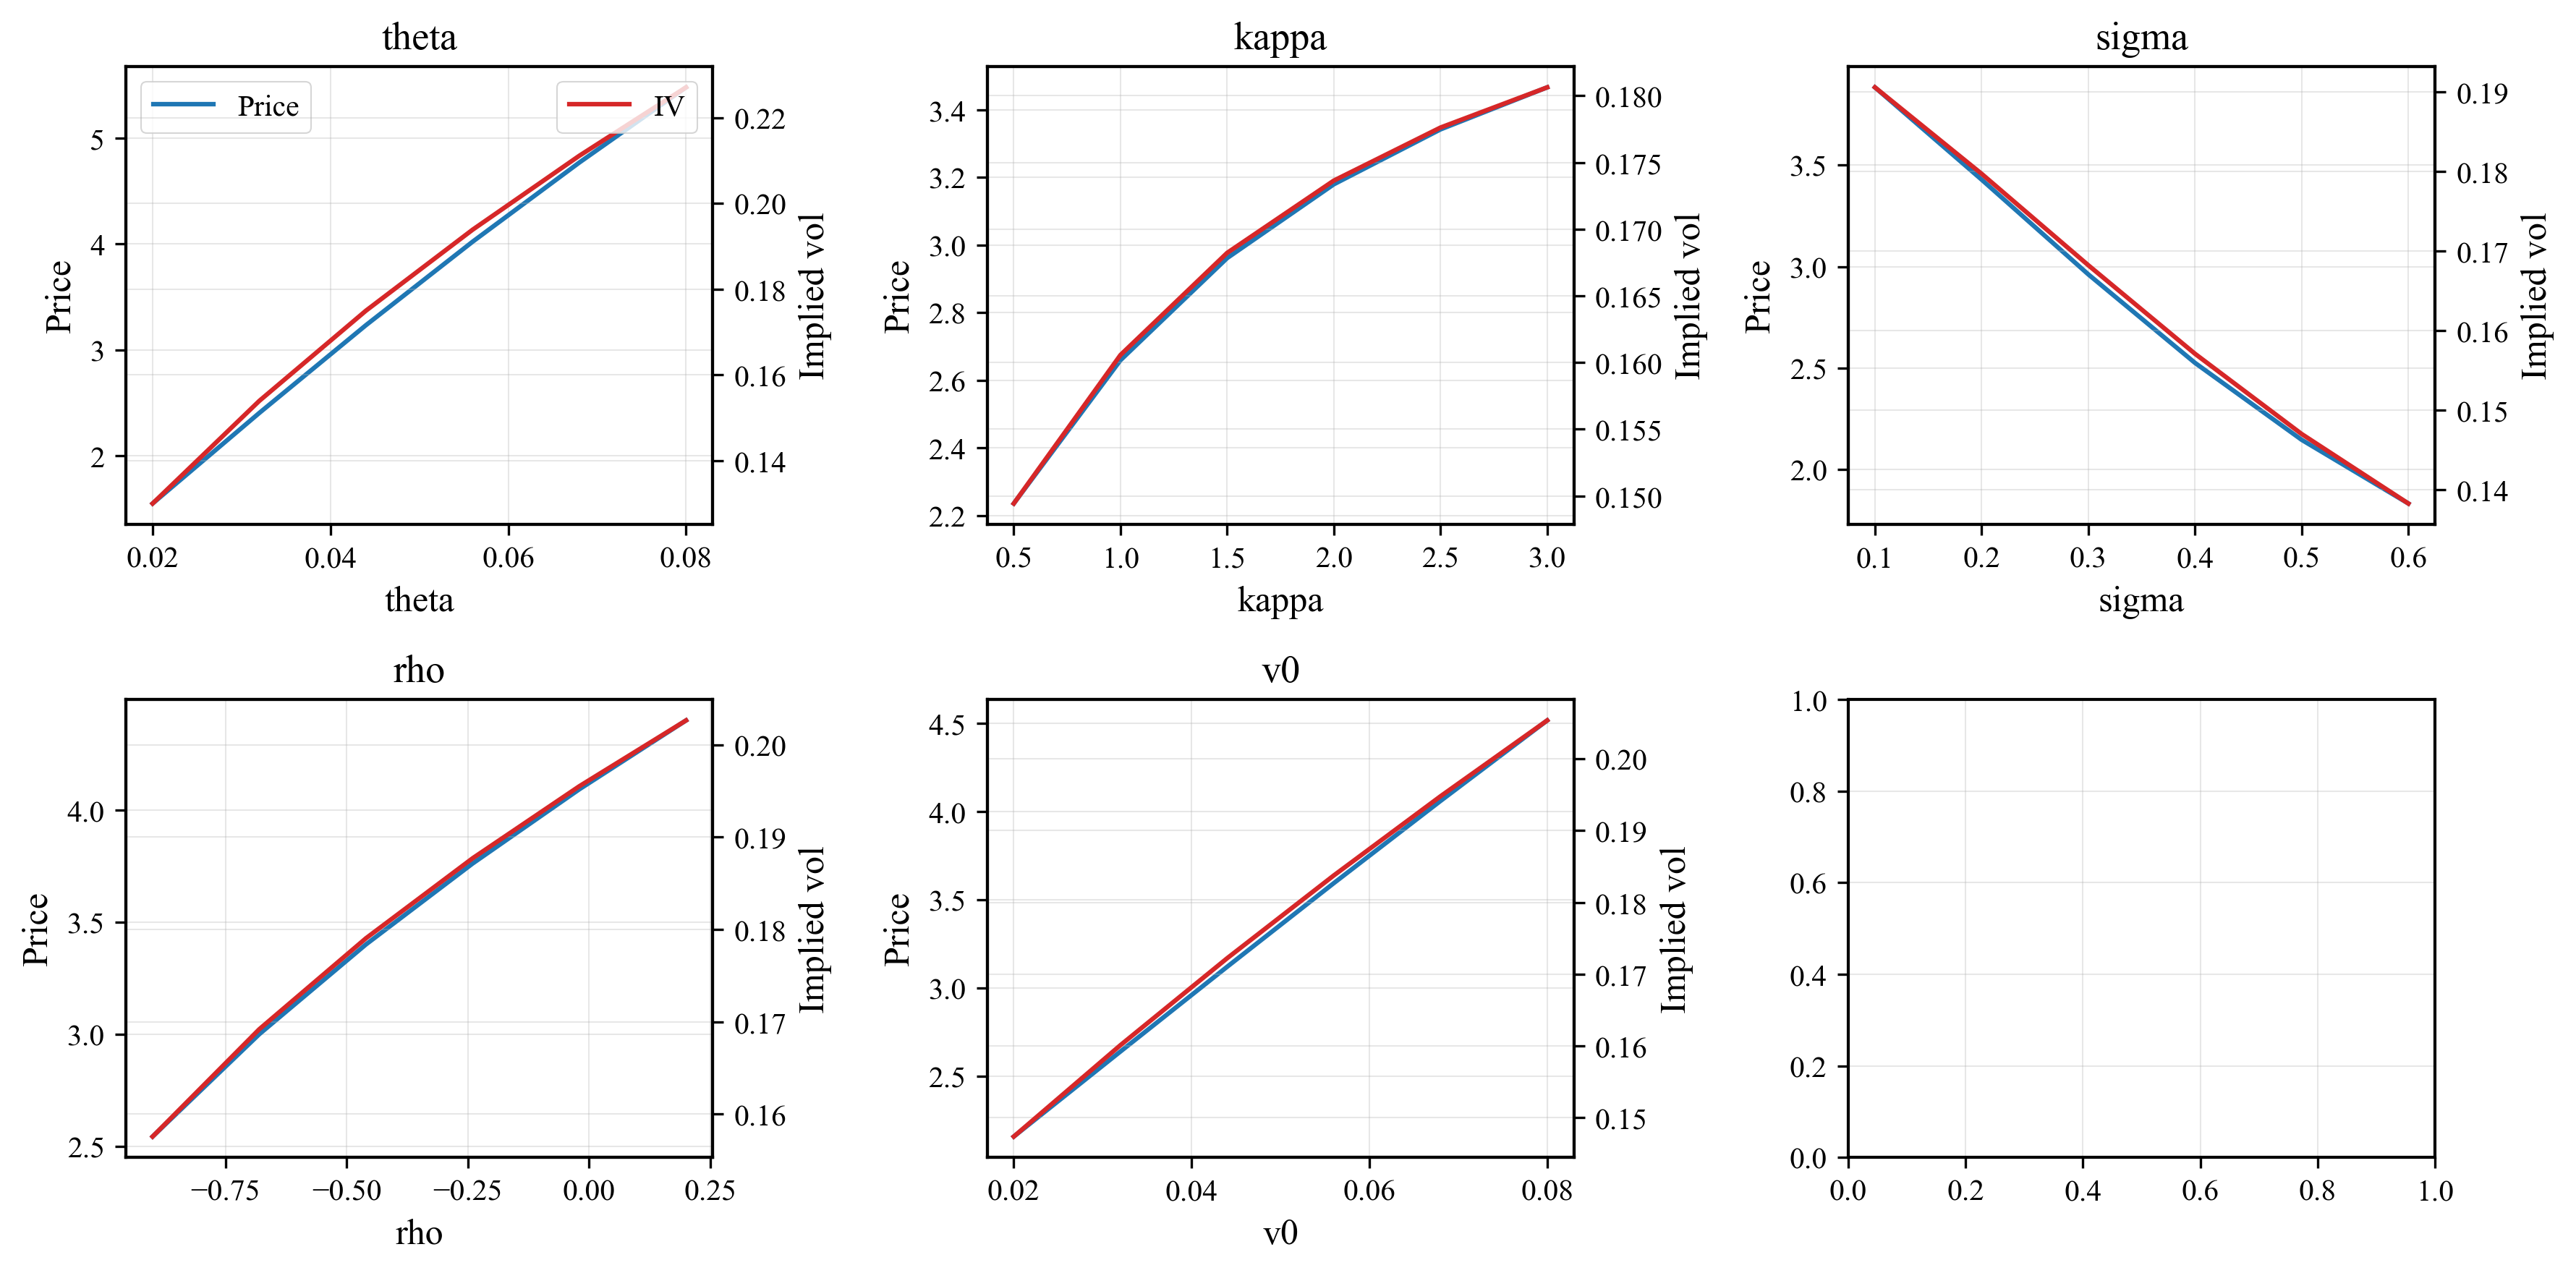

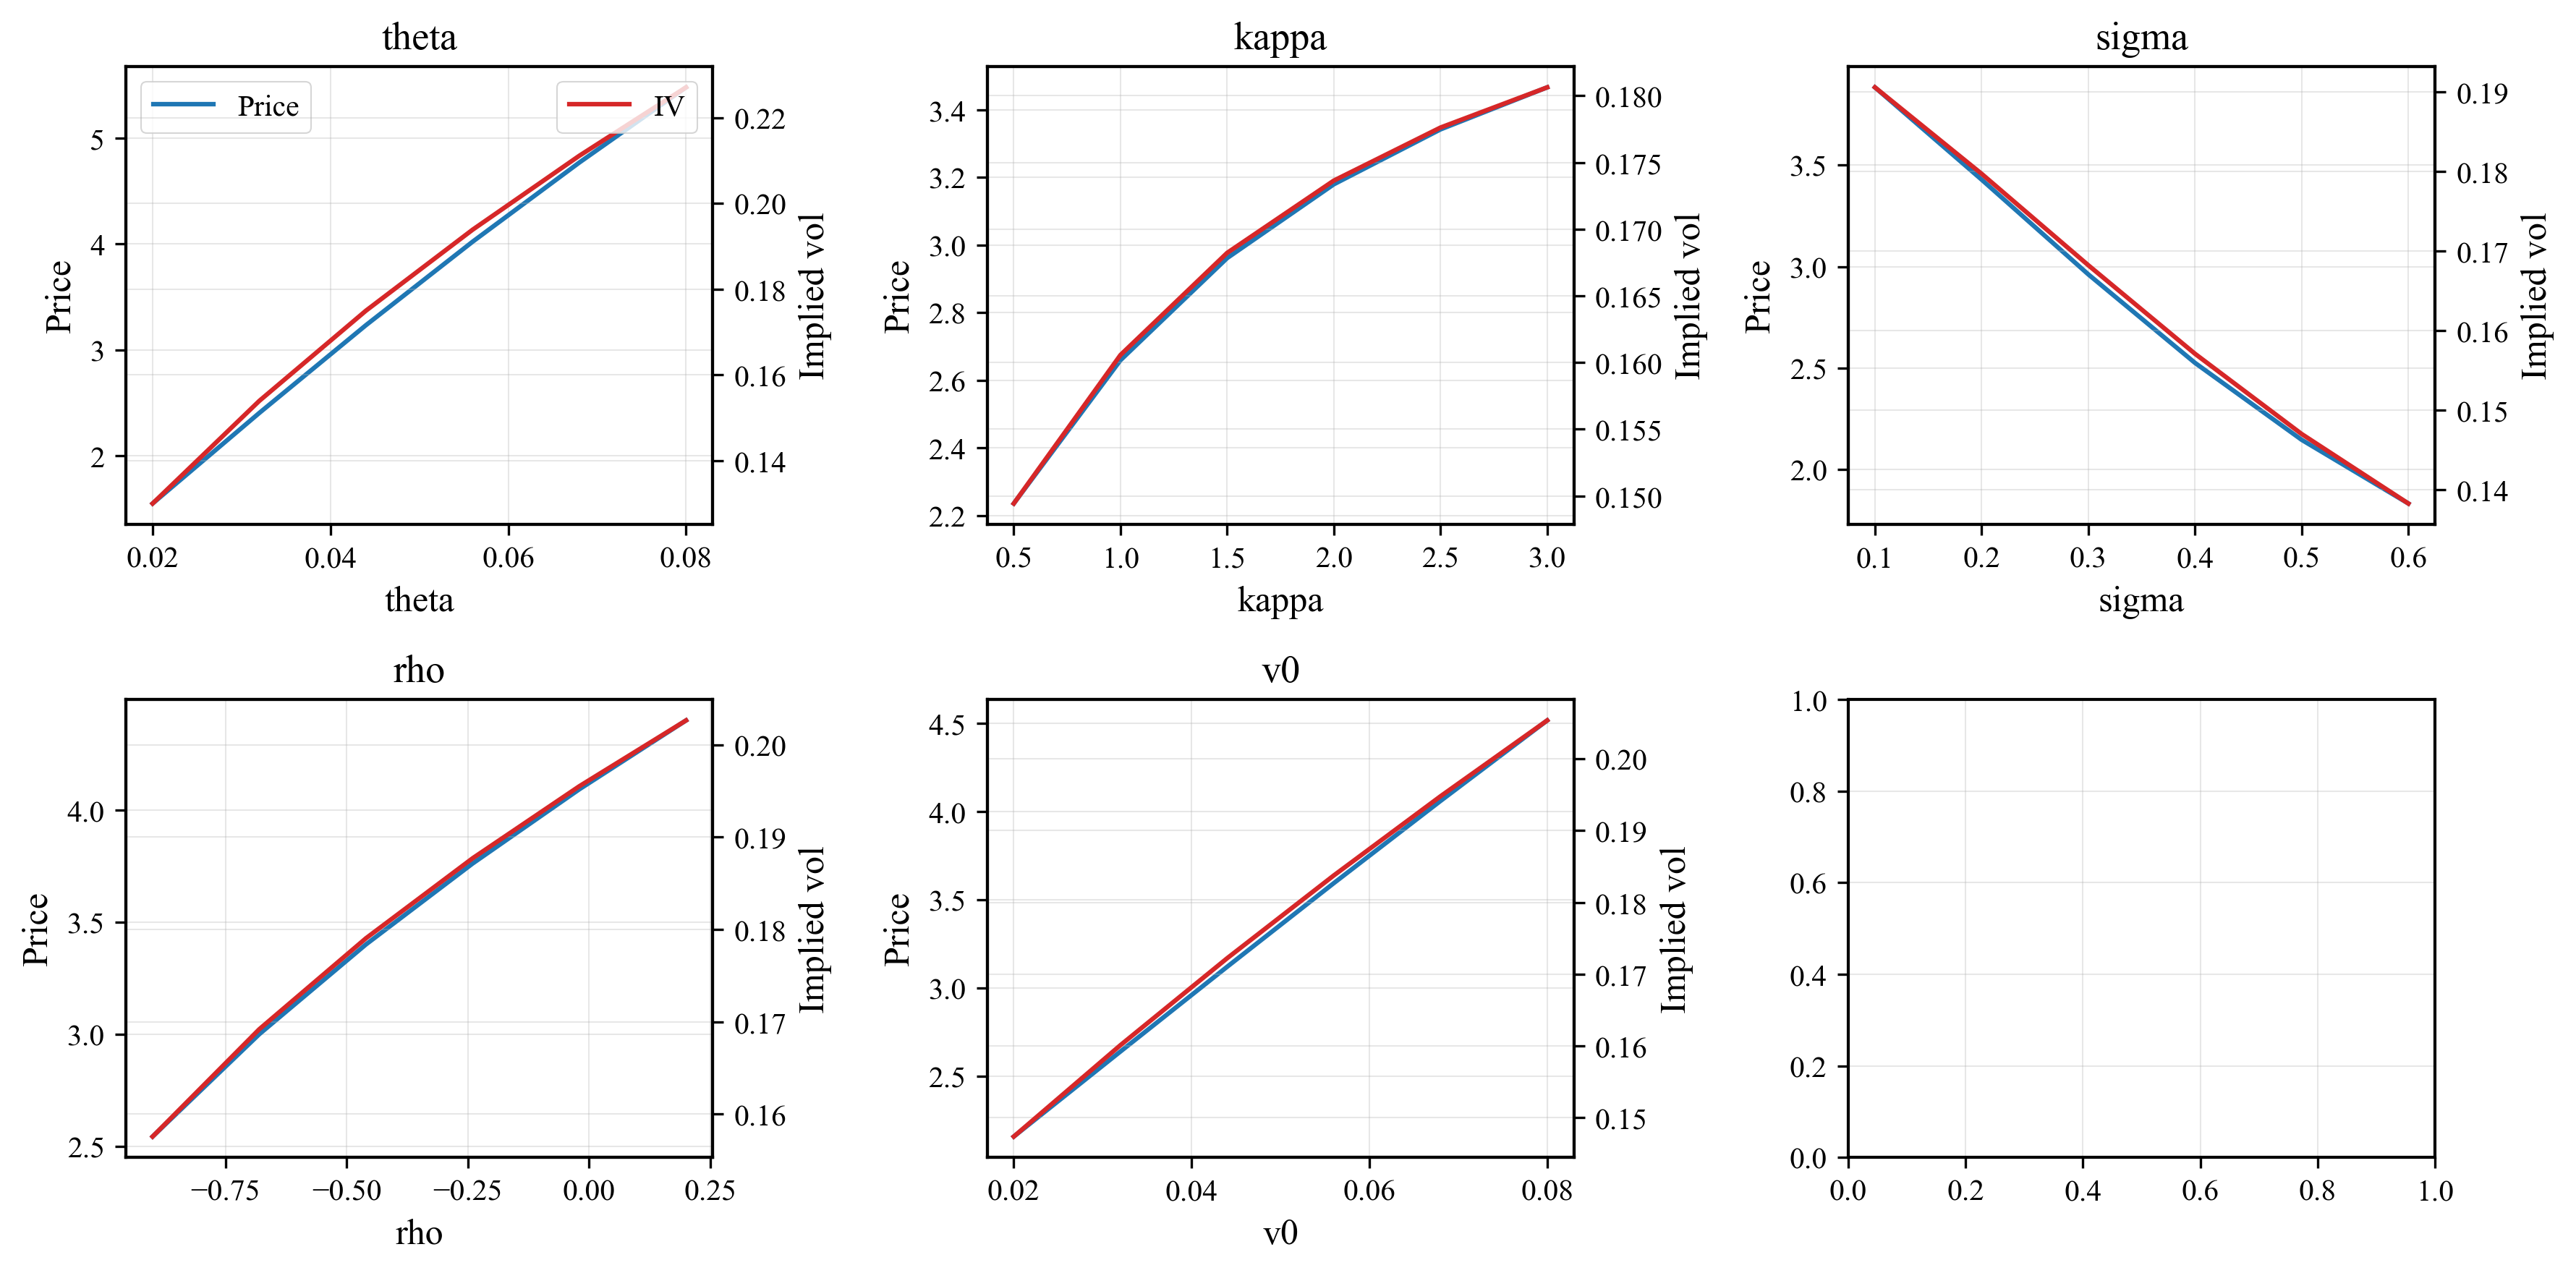

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()
for idx, (name, df) in enumerate(sweep_results.items()):
    ax = axes[idx]
    ax.plot(df["value"], df["price"], label="Price")
    ax2 = ax.twinx()
    ax2.plot(df["value"], df["iv"], color="tab:red", label="IV")
    ax.set_title(name)
    ax.set_xlabel(name)
    ax.set_ylabel("Price")
    ax2.set_ylabel("Implied vol")
    if idx == 0:
        ax.legend(loc="upper left")
        ax2.legend(loc="upper right")
plt.tight_layout()
fig

## FFT error heatmap across strikes/maturities

The earlier tuning grid looked at a single strike/maturity. Below we compute `|FFT - quad|` over a strike/maturity mesh using the tuned FFT parameters to confirm accuracy across the surface.


In [13]:
heat_strikes = np.linspace(80, 120, 9)
heat_maturities = np.linspace(0.25, 1.5, 8)
errors = np.zeros((len(heat_maturities), len(heat_strikes)))
for i, tau in enumerate(heat_maturities):
    for j, K in enumerate(heat_strikes):
        fft_price = model.call_price_fft(S0, K, tau, N=8192, eta=0.05, alpha=1.3)
        quad_price = model.call_price(S0, K, tau, method="quad")
        errors[i, j] = abs(fft_price - quad_price)
errors[:3, :3]

array([[0.29223638, 0.26301721, 0.21703898],
       [0.48565342, 0.4303796 , 0.35501992],
       [0.67484863, 0.59605685, 0.49562882]])

In [14]:
fig = go.Figure(
    data=[
        go.Surface(
            x=heat_strikes,
            y=heat_maturities,
            z=errors,
            colorscale="Inferno",
            showscale=True,
        )
    ]
)
fig.update_layout(
    title="|FFT - quad| error surface",
    scene=dict(
        xaxis_title="Strike",
        yaxis_title="Maturity (years)",
        zaxis_title="Absolute error",
    ),
    width=750,
    height=500,
)
fig

## Volatility scenario comparison

Different parameter choices (e.g. changing correlation `rho` or volatility of volatility `sigma`) create dramatically different implied-vol surfaces. Below we define a couple of scenarios and plot their surfaces for quick qualitative comparison.


In [15]:
scenarios = {
    "baseline": params,
    "high_sigma": {**params, "sigma": 0.6},
    "low_rho": {**params, "rho": -0.3},
    "neutral_rho": {**params, "rho": 0.0},
}

scenario_vols = {}
for name, params in scenarios.items():
    model = HestonModel(**params)
    vols = np.zeros_like(implied_vols)
    for i, tau in enumerate(vol_maturities):
        for j, K in enumerate(vol_strikes):
            price = model.call_price_fft(S0, K, tau, **fft_params)
            vols[i, j] = implied_vol(price, S0, K, tau, model.r, model.q)
    scenario_vols[name] = vols

scenario_vols["baseline"][:3, :3]

array([[0.24431636, 0.23846441, 0.23263244],
       [0.24114413, 0.23548895, 0.22985388],
       [0.23825758, 0.2327988 , 0.22736516]])

In [18]:
fig = go.Figure()
for name, vols in scenario_vols.items():
    fig.add_trace(
        go.Surface(
            x=vol_strikes,
            y=vol_maturities,
            z=vols,
            name=name,
            showscale=False,
            opacity=0.7,
        )
    )
fig.update_layout(
    title="Scenario implied vol surfaces",
    scene=dict(
        xaxis_title="Strike",
        yaxis_title="Maturity (years)",
        zaxis_title="Implied vol",
    ),
    width=800,
    height=600,
)
fig

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'name': 'baseline',
              'opacity': 0.7,
              'showscale': False,
              'type': 'surface',
              'x': {'bdata': ('AAAAAAAAVEAAAAAAAKBUQAAAAAAAQF' ... 'AAwFxAAAAAAABgXUAAAAAAAABeQA=='),
                    'dtype': 'f8'},
              'y': {'bdata': ('AAAAAAAA0D94d3d3d3fXP+/u7u7u7t' ... 'RERET8PyIiIiIiIv4/AAAAAAAAAEA='),
                    'dtype': 'f8'},
              'z': {'bdata': ('jbp2JsJFzz98ax9uAIbOPx83Z1jmxs' ... '/Fo8Y/XzrP9HpWxj8Df9w0hQrGPw=='),
                    'dtype': 'f8',
                    'shape': '16, 17'}},
             {'name': 'high_sigma',
              'opacity': 0.7,
              'showscale': False,
              'type': 'surface',
              'x': {'bdata': ('AAAAAAAAVEAAAAAAAKBUQAAAAAAAQF' ... 'AAwFxAAAAAAABgXUAAAAAAAABeQA=='),
                    'dtype': 'f8'},
              'y': {'bdata': ('AAAAAAAA0D94d3d3d3fXP+/u7u7u7t' ... 'RERET8PyIiIiIiIv4/AAAAAAAAAEA='),
                    'dtype': 'f8'},
              'z': {'bdata': ('d1868H2a0T/TgHCKS/fQP/1h/xfxUN' ... 'ohQsM/PgS4Jj/Owj8nP8gjamPCPw=='),
                    'dtype': 'f8',
                    'shape': '16, 17'}},
             {'name': 'low_rho',
              'opacity': 0.7,
              'showscale': False,
              'type': 'surface',
              'x': {'bdata': ('AAAAAAAAVEAAAAAAAKBUQAAAAAAAQF' ... 'AAwFxAAAAAAABgXUAAAAAAAABeQA=='),
                    'dtype': 'f8'},
              'y': {'bdata': ('AAAAAAAA0D94d3d3d3fXP+/u7u7u7t' ... 'RERET8PyIiIiIiIv4/AAAAAAAAAEA='),
                    'dtype': 'f8'},
              'z': {'bdata': ('KKQrF0YazT/+iEy8F4jMP7yL0CQl+8' ... 'dnB8g/5NcriQvxxz8GimyTetzHPw=='),
                    'dtype': 'f8',
                    'shape': '16, 17'}},
             {'name': 'neutral_rho',
              'opacity': 0.7,
              'showscale': False,
              'type': 'surface',
              'x': {'bdata': ('AAAAAAAAVEAAAAAAAKBUQAAAAAAAQF' ... 'AAwFxAAAAAAABgXUAAAAAAAABeQA=='),
                    'dtype': 'f8'},
              'y': {'bdata': ('AAAAAAAA0D94d3d3d3fXP+/u7u7u7t' ... 'RERET8PyIiIiIiIv4/AAAAAAAAAEA='),
                    'dtype': 'f8'},
              'z': {'bdata': ('RCoS7Vkoyz9d2+rw+cDKPyFnEiSSY8' ... 'Rk7sg/UVviDIn6yD9tk3WtlwfJPw=='),
                    'dtype': 'f8',
                    'shape': '16, 17'}}],
    'layout': {'height': 600,
               'scene': {'xaxis': {'title': {'text': 'Strike'}},
                         'yaxis': {'title': {'text': 'Maturity (years)'}},
                         'zaxis': {'title': {'text': 'Implied vol'}}},
               'template': '...',
               'title': {'text': 'Scenario implied vol surfaces'},
               'width': 800}
})

## Simulation accuracy vs FFT

We reuse the `HestonSimulator` module to price an option via Monte Carlo across multiple strikes and maturities and compare against FFT. This provides a cross-check before calibration.


In [16]:
from src.heston_model import HestonModel

# Create Heston model instance (simulation now integrated in HestonModel)
model_sim = HestonModel(
    kappa=params["kappa"],
    theta=params["theta"],
    sigma=params["sigma"],
    rho=params["rho"],
    v0=params["v0"],
    r=params["r"],
    q=params["q"],
)

def mc_price(S0, K, tau, n_paths=20000, n_steps=252, seed=123):
    """Monte Carlo option pricing using HestonModel.simulate_paths()"""
    times, spots, _ = model_sim.simulate_paths(S0, tau, n_steps, n_paths, seed=seed)
    payoffs = np.maximum(spots[:, -1] - K, 0)
    disc = np.exp(-model_sim.r * tau)
    mean = disc * payoffs.mean()
    stderr = disc * payoffs.std(ddof=1) / np.sqrt(n_paths)
    return mean, stderr

In [17]:
mc_strikes = [80, 100, 120]
mc_maturities = [0.5, 1.0]
records = []
for tau in mc_maturities:
    for K in mc_strikes:
        mean, stderr = mc_price(S0, K, tau)
        fft_val = model.call_price_fft(S0, K, tau, **fft_params)
        records.append(
            {
                "strike": K,
                "maturity": tau,
                "mc_price": mean,
                "mc_ci": 1.96 * stderr,
                "fft_price": fft_val,
                "abs_diff": abs(mean - fft_val),
            }
        )
pd.DataFrame(records)

,strike,maturity,mc_price,mc_ci,fft_price,abs_diff
0,80,0.5,21.096461,0.189782,21.110841,0.014381
1,100,0.5,5.961492,0.131968,5.977417,0.015925
2,120,0.5,0.890759,0.056903,0.870028,0.020730
3,80,1.0,22.574760,0.261431,22.593707,0.018947
4,100,1.0,8.664960,0.197114,8.667118,0.002157
5,120,1.0,2.508738,0.119280,2.486086,0.022652


The differences should fall inside the Monte Carlo confidence intervals, confirming that the simulator is consistent with the analytical Heston pricing routine. Otherwise, as here, it shows that FFT has a tail bias.


## Why tails and long maturities are harder for FFT

Carr–Madan’s FFT prices options on a *fixed log-strike grid*. When the option we care about sits near the edges of that grid—deep ITM/OTM strikes or very long maturities—the following issues pop up:

1. **Sparse strike coverage**: with large `Δk` (set by `eta` and `N`), deep strikes end up between far-apart nodes, so interpolation dominates the price.
2. **Damping sensitivity**: extreme payoffs rely more on the exponential damping factor `alpha`. Too much damping underprices far tails; too little causes oscillations. Longer maturities amplify the effect because the characteristic function decays more slowly.
3. **Finite frequency window**: FFT integrates over an implicit frequency interval. Long maturities broaden the integrand; if the window is too narrow, tail energy is truncated, unlike `quad` which adapts its limits.
